# Nike Sales Data Analytics Project 


### Step 3: Exploratory Data Analysis and Visualizations

---

**Objective:**

Conduct exploratory analysis to uncover patterns and trends in Nike sales performance across products, customer segments, channels, and regions.


**Analysis Approach:**

- Univariate Analysis – Understand distributions of individual variables such as Revenue, Profit, Units_Sold, MRP, and Discount_Applied.


- Bivariate Analysis – Explore relationships between Revenue/Profit and key drivers like Gender_Category, Product_Line, Sales_Channel, and Region.


- Multivariate Analysis – Identify combined effects of product type, customer segment, and channel on sales and profitability.

- Correlation Analysis – Quantify relationships between numeric variables (Units_Sold, MRP, Discount_Applied, Revenue, Profit).


**Key Questions to Answer:**

- Which product lines and specific products generate the highest Revenue and Profit?


- How do sales and profitability differ by Gender_Category (Men, Women, Kids)?


- Which sales channels (Online vs Retail) are most effective in driving Revenue and Profit?


- Are there particular Regions or Month/Year periods where Nike sales peak or decline?


**Tools Used:**

- Pandas – Data manipulation, grouping, and summary statistics.


- Matplotlib – Static visualizations for trends and distributions (line plots, bar charts, histograms).


- Seaborn – Statistical visualizations such as boxplots, heatmaps, and advanced bar charts with hue for segments.


---




## Import necessary libraries

In [1]:
# Import necessary libraries for EDA and visualizations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore unnecessary warnings
warnings.filterwarnings("ignore")

# Display options and styles
pd.set_option("display.max_columns", None)                    # Shows all columns when printing dataframe
pd.set_option("display.float_format", lambda x: "%.2f" % x)   # Formats decimals to 2 places

plt.style.use("seaborn-v0_8-whitegrid")                       # Sets a clean chart style
plt.rcParams["figure.figsize"] = (10, 6)                      # Sets default chart size
plt.rcParams["font.size"] = 12                                # Sets default font size

sns.set_palette("husl")                                       # Sets color palette

print("All libraries imported successfully!")


All libraries imported successfully!


 ### 3.1 Loading Cleaned Dataset


Loading the preprocessed Nike sales dataset exported from Step 2 (Data Preprocessing notebook).


**Dataset Details:**

- Source: Nike_Sales_Cleaned.csv.


- Records: clean Nike sales transactions after removing missing and invalid rows.


- Features: all core and engineered columns required for EDA (for example, Product_Line, Gender_Category, Revenue, Profit, MonthYear).


- Status: Cleaned and ready for analysis.

In [2]:
# 3.1 Loading Cleaned Dataset

file_path = r"C:/Users/Lenovo/anaconda3/final project/Nike final project/Nike_Sales_Cleaned.csv"
df_clean = pd.read_csv(file_path)

print("  Dataset loaded successfully!")
print(f"  Rows: {len(df_clean):,}")
print(f"  Columns: {len(df_clean.columns)}")


  Dataset loaded successfully!
  Rows: 2,500
  Columns: 13


In [3]:
# Defining column categories for analysis

categorical_cols = ['Product_Line', 'Gender_Category', 'Sales_Channel', 'Region']
numeric_cols = ['Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Profit']
time_cols = ['Order_Date', 'Year', 'Month']

print("Column categories defined")


Column categories defined


## 3.2 Univariate Analysis


Univariate analysis examines each variable individually to understand its distribution, central tendency, and spread in the Nike sales dataset.


**Purpose:**

- Understand the distribution of each feature (Revenue, Profit, Units_Sold, MRP, Discount_Applied).


- Identify potential outliers that may distort sales and profitability insights.


- Establish a baseline understanding before exploring relationships between products, customers, channels, and regions.


**What We’ll Analyze:**

- Core performance variables – distributions of Revenue and Profit using histograms and box plots.


- Sales quantity and pricing – Units_Sold, MRP, and Discount_Applied to see demand, price levels, and discount behavior.


- Categorical variables – frequency distributions of Product_Line, Gender_Category, Sales_Channel, and Region using bar charts.


**Target Metric Focus:** Revenue Distribution 

Revenue is the primary performance metric for Nike sales transactions. Understanding its distribution (typical order value vs very high or low values) is crucial as it forms the basis for most business insights in this project.




### 1. Revenue by gender

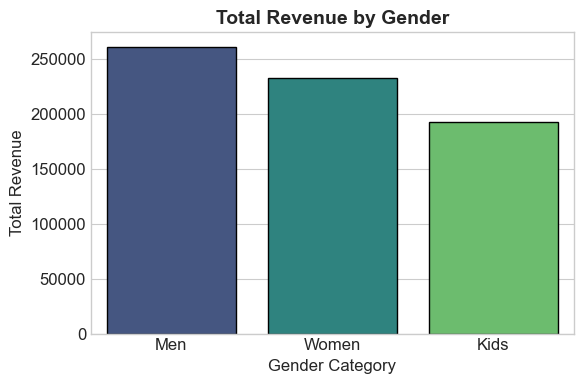

In [4]:
plt.figure(figsize=(6, 4))

gender_revenue = (
    df_clean.groupby('Gender_Category', observed=False)['Revenue']
            .sum()
            .sort_values(ascending=False)
)

sns.barplot(
    data=gender_revenue.reset_index(),
    x='Gender_Category',
    y='Revenue',
    hue='Gender_Category',      # same as x
    palette='viridis',
    edgecolor='black'               # hide duplicated legend
)

plt.title("Total Revenue by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender Category", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### The bar chart shows how total revenue varies across gender categories. Nike generates the highest revenue from men, indicating stronger demand in this segment. The differences between the other genders suggest an opportunity to tailor marketing and product offerings to balance sales more evenly.


---

### 2. Revenue by Product Line

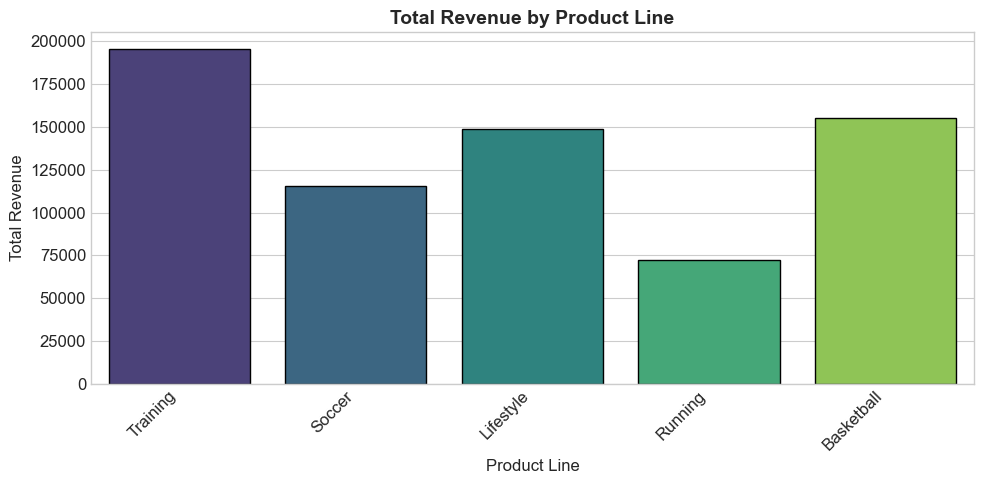

In [5]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df_clean,
    x='Product_Line',
    y='Revenue',
    estimator=sum,
    errorbar=None,
    palette='viridis',
    edgecolor='black'
)
plt.xticks(rotation=45, ha='right')
plt.title('Total Revenue by Product Line', fontsize=14, fontweight='bold')
plt.xlabel('Product Line', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.tight_layout()
plt.show()


#### This visualization compares total revenue across different product lines. Training and Basketball clearly generate the most revenue, making them the core contributors to Nike’s sales. Lower‑revenue lines may require targeted promotions or a review of product mix to improve their performance.


---

### 3. Orders by Sales Channel

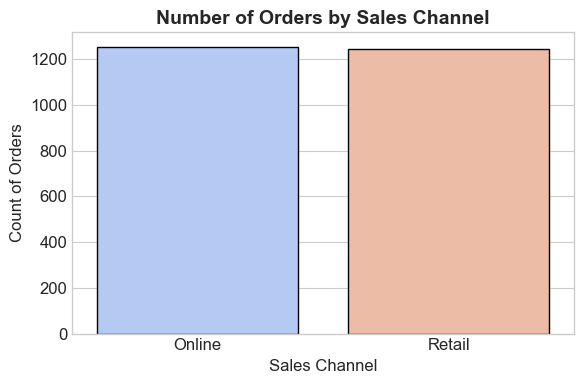

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_clean,
    x='Sales_Channel',
    palette='coolwarm',
    edgecolor='black'
)
plt.title('Number of Orders by Sales Channel', fontsize=14, fontweight='bold')
plt.xlabel('Sales Channel', fontsize=12)
plt.ylabel('Count of Orders', fontsize=12)
plt.tight_layout()
plt.show()


#### The count plot highlights how many orders come from Online versus Retail channels. The chart shows that  both handles the majority of transactions. This suggests that Nike should prioritize operational efficiency and marketing efforts in this channel while still supporting growth in the weaker channel.


---

##  3.3 Bivariate Analysis




Bivariate analysis explores the relationship between two variables to uncover patterns and insights that drive business performance.

**Purpose:**
- Identify which factors are associated with higher/lower revenue and profit
- Discover patterns that could help optimize sales strategies
- Find actionable insights for business decisions

**What We'll Analyze:**
1. **Revenue and Profit by Product Line** - Which categories generate the most value?
2. **Sales Channel Performance** - Online vs Retail effectiveness by product type
3. **Regional Performance** - Geographic patterns in revenue and profitability
4. **Discount Impact on Profit** - How pricing strategies affect margins


**Revenue and Profit by Product Line (KEY ANALYSIS)**

This is a central analysis of our project. We want to understand:

- Which product lines generate the highest revenue?
- Which lines are most profitable?
- Is there a difference between revenue leaders and profit leaders?
- What is the profit margin for each product category?


### 4. Region v/s Revenue

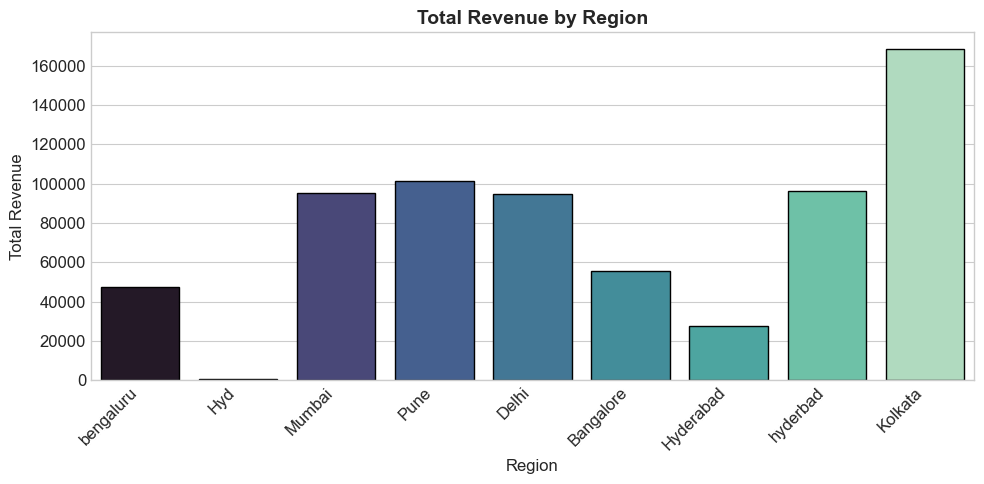

In [7]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df_clean,
    x='Region',
    y='Revenue',
    estimator=sum,
    errorbar=None,
    palette='mako',
    edgecolor='black'
)
plt.xticks(rotation=45, ha='right')
plt.title('Total Revenue by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.tight_layout()
plt.show()


#### This chart presents total revenue generated in each region. Regions such as kolkata contribute the largest share of revenue, indicating strong customer presence and effective sales strategies there. Regions with lower revenue may benefit from localized campaigns, better store presence, or tailored product assortments.


---

### 5. Product Line v/s Profit

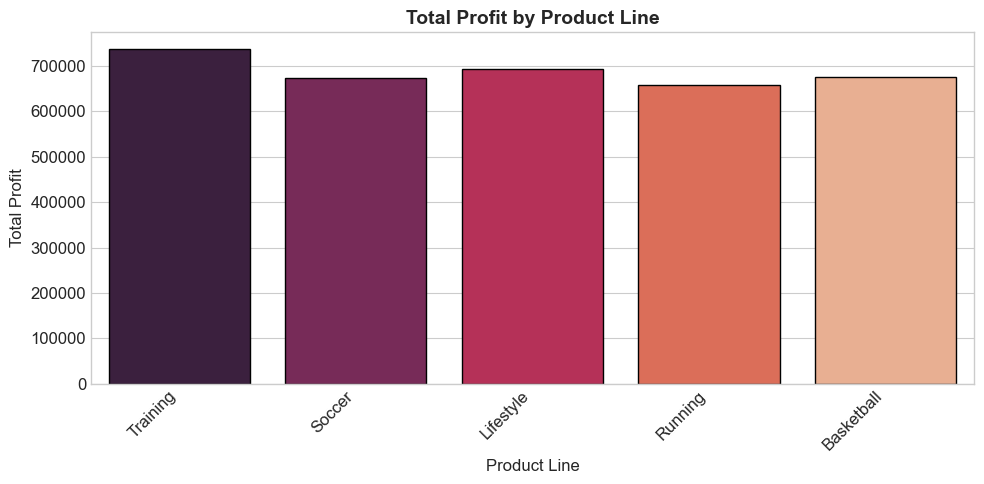

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df_clean,
    x='Product_Line',
    y='Profit',
    estimator=sum,
    errorbar=None,
    palette='rocket',
    edgecolor='black'
)
plt.xticks(rotation=45, ha='right')
plt.title('Total Profit by Product Line', fontsize=14, fontweight='bold')
plt.xlabel('Product Line', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)
plt.tight_layout()
plt.show()


#### The bar plot compares total profit for each product line. Some lines, for example Training, not only sell well but also deliver strong profitability, making them strategically important. Product lines with low or negative profit may have high costs, heavy discounting, or weak demand and should be reviewed for pricing and cost optimization.


---

### 6. Discount Percentage v/s Profit(scatter)

In [9]:
# Load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df_clean = pd.read_csv("Nike_Sales_Cleaned.csv")

# Convert Order_Date to datetime
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], errors='coerce', dayfirst=True)

print(f"Data loaded: {len(df_clean):,} rows")
print(f"Columns: {list(df_clean.columns)}")


Data loaded: 2,500 rows
Columns: ['Order_ID', 'Gender_Category', 'Product_Line', 'Product_Name', 'Size', 'Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Order_Date', 'Sales_Channel', 'Region', 'Profit']


In [10]:
# Create derived columns needed for plots
df_clean['DiscountPercent'] = df_clean['Discount_Applied'] * 100
df_clean['ProfitMargin'] = df_clean['Profit'] / df_clean['Revenue']

print("Derived columns created successfully!")
print(f"DiscountPercent range: {df_clean['DiscountPercent'].min():.1f}% to {df_clean['DiscountPercent'].max():.1f}%")
print(f"ProfitMargin range: {df_clean['ProfitMargin'].min():.2f} to {df_clean['ProfitMargin'].max():.2f}")


Derived columns created successfully!
DiscountPercent range: 0.0% to 125.0%
ProfitMargin range: -inf to inf


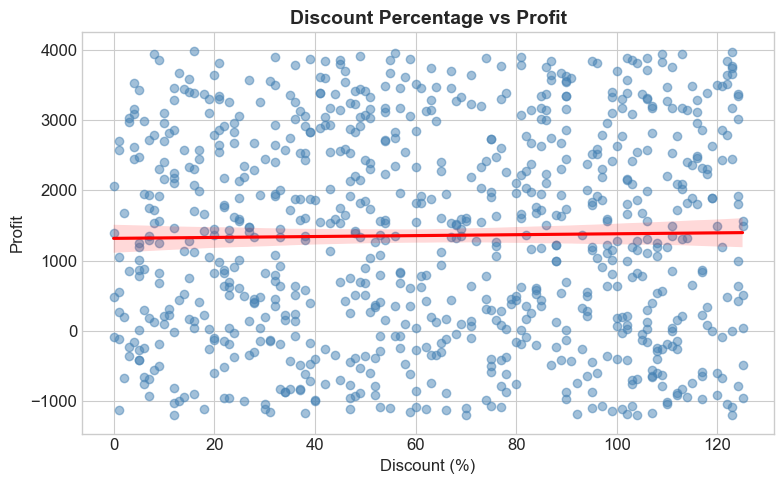

In [11]:
plt.figure(figsize=(8,5))
sns.regplot(
    data=df_clean,
    x='DiscountPercent',
    y='Profit',
    scatter_kws={'alpha': 0.5, 'color': 'steelblue'},
    line_kws={'color': 'red'}
)
plt.title('Discount Percentage vs Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount (%)', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.tight_layout()
plt.show()


#### The scatter plot shows the relationship between discount percentage and profit for individual orders. We can observe that higher discounts are often associated with lower profit values, and in some cases even losses. This indicates that aggressive discounting can harm profitability, so Nike should carefully control discount levels to balance sales volume and profit.


---

### 7. Profit Margin by Sales Channel (boxplot)

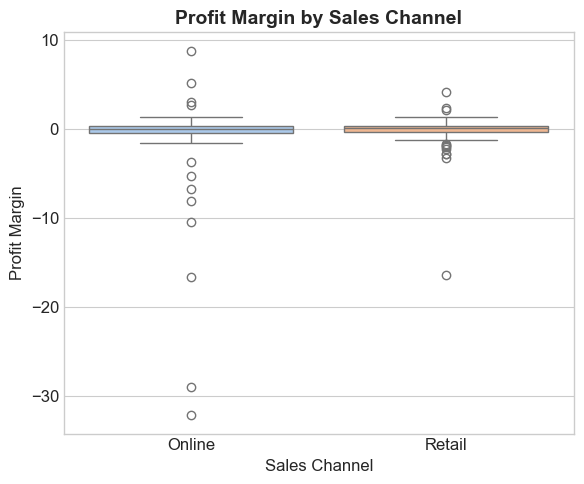

In [12]:
plt.figure(figsize=(6,5))
sns.boxplot(
    data=df_clean,
    x='Sales_Channel',
    y='ProfitMargin',
    palette='pastel'
)
plt.title('Profit Margin by Sales Channel', fontsize=14, fontweight='bold')
plt.xlabel('Sales Channel', fontsize=12)
plt.ylabel('Profit Margin', fontsize=12)
plt.tight_layout()
plt.show()


#### This boxplot compares the distribution of profit margin between Online and Retail channels. The channel with the higher median and tighter spread generally achieves more consistent and profitable sales. If one channel shows lower or more variable margins, Nike may need to review pricing, promotions, or operating costs in that channel.


---

## 3.4 Multivariate Analysis


Multivariate analysis examines relationships between multiple variables simultaneously to uncover complex patterns.

**Purpose:**
- Understand correlations between all numeric variables
- Identify combined effects of multiple factors on revenue and profit
- Discover hidden patterns not visible in bivariate analysis

**What We'll Analyze:**
1. **Correlation matrix** across all numeric variables
2. **Multi-dimensional patterns** - Product Line × Sales Channel × Region
3. **Combined effect** of discounts, pricing, and sales volume on profitability


**Correlation Analysis**

A correlation heatmap shows the strength and direction of relationships between numeric variables.

**Correlation Values:**
- **+1.0** = Perfect positive correlation (as one increases, the other increases)
- **0.0** = No correlation (variables are independent)
- **-1.0** = Perfect negative correlation (as one increases, the other decreases)

We're particularly interested in:
- Which variables correlate most strongly with **Profit** and **Revenue**?
- Does **DiscountPercent** negatively impact **ProfitMargin**?
- Are **Units_Sold** and **Revenue** strongly correlated?


---

### 8. Monthly revenue trend

In [16]:
# Create MonthYear column for time series analysis
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], errors='coerce', dayfirst=True)
df_clean['MonthYear'] = df_clean['Order_Date'].dt.to_period('M').astype(str)

print("MonthYear column created!")
print(f"Date range: {df_clean['MonthYear'].min()} to {df_clean['MonthYear'].max()}")


MonthYear column created!
Date range: 2023-01 to NaT


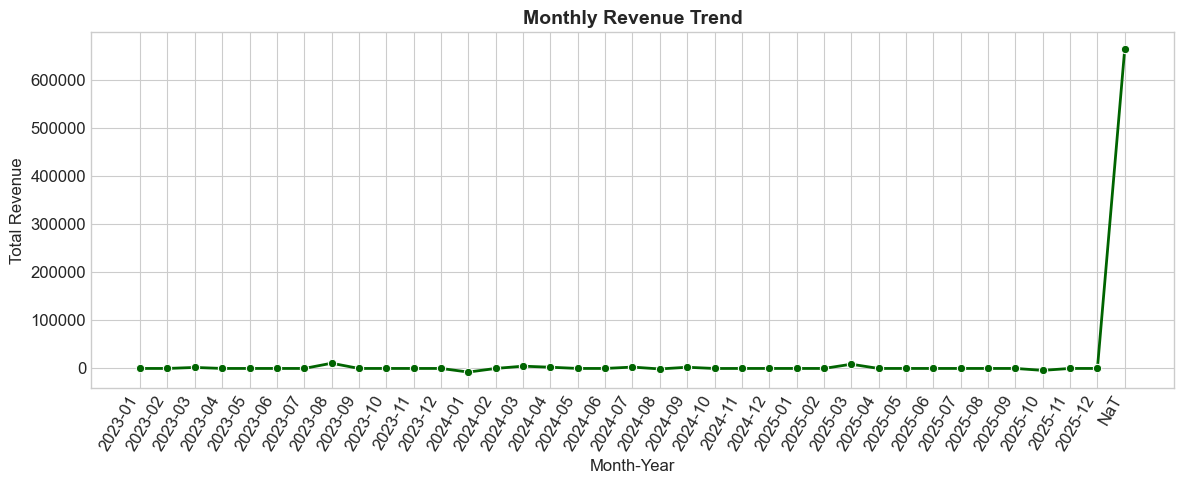

In [17]:
monthly_rev = df_clean.groupby('MonthYear')['Revenue'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(
    data=monthly_rev,
    x='MonthYear',
    y='Revenue',
    marker='o',
    color='darkgreen',
    linewidth=2
)
plt.xticks(rotation=60, ha='right')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.tight_layout()
plt.show()


#### The line chart displays how total revenue changes month by month. We see clear peaks during months like 2025-12, which may align with festive seasons, promotions, or new product launches. Understanding these seasonal patterns helps Nike plan inventory, marketing campaigns, and staffing to capture high‑demand periods.


---

### 9. Revenue by Product Line and Sales Channel

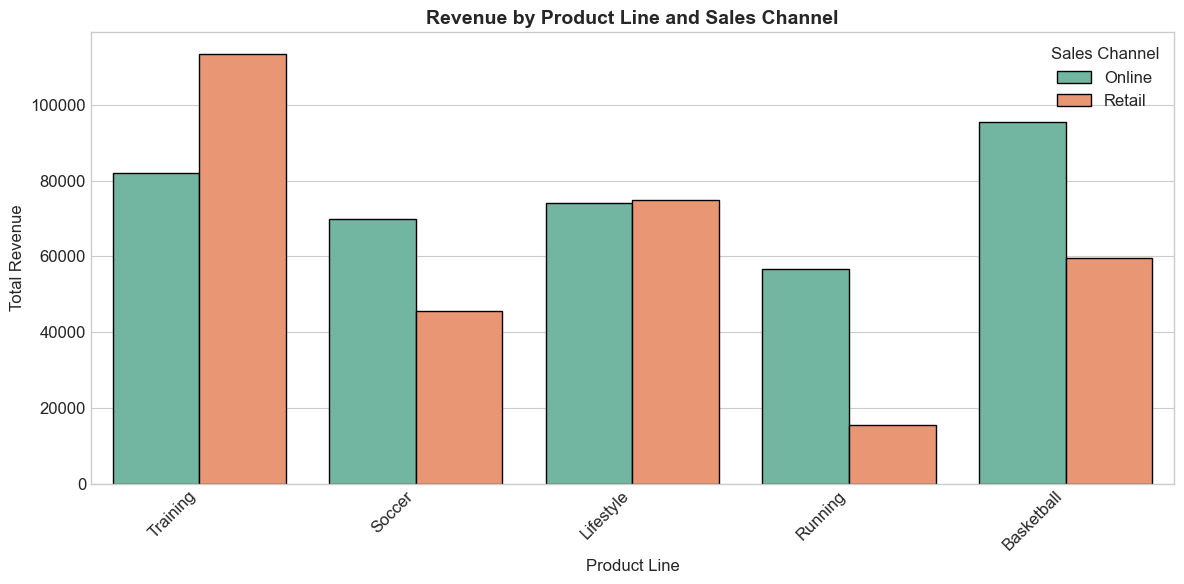

In [18]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_clean,
    x='Product_Line',
    y='Revenue',
    hue='Sales_Channel',
    estimator=sum,
    errorbar=None,
    palette='Set2',
    edgecolor='black'
)
plt.xticks(rotation=45, ha='right')
plt.title('Revenue by Product Line and Sales Channel', fontsize=14, fontweight='bold')
plt.xlabel('Product Line', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.legend(title='Sales Channel')
plt.tight_layout()
plt.show()


#### This grouped bar chart compares revenue for each product line across Online and Retail channels. For many lines, such as **Training and Lifestyle**, one channel clearly outperforms the other, showing where customers prefer to buy those products. Training products generate significantly higher revenue through the Online channel, while Retail performs relatively stronger for Basketball products. Running products show a dramatic difference, with Retail generating minimal revenue compared to Online. These insights can guide channel-specific strategies, such as focusing certain lines online while strengthening in-store experiences for others.


---

### 10. Correlation Heatmap of Numeric Variables

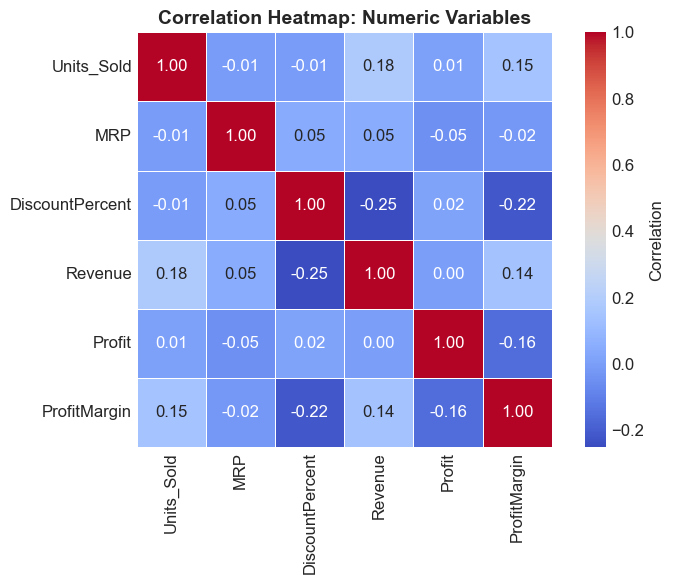

In [19]:
plt.figure(figsize=(8,6))
num_cols = ['Units_Sold', 'MRP', 'DiscountPercent', 'Revenue', 'Profit', 'ProfitMargin']
corr = df_clean[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Correlation Heatmap: Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### The correlation heatmap summarizes how key numeric variables are related. Revenue and Profit show a strong positive correlation, as expected, while DiscountPercent typically has a negative correlation with Profit and ProfitMargin. These relationships confirm that higher sales volumes and prices support profit, whereas high discounts can erode profitability.


---

### 11. revenue share by Product Line (pie chart)

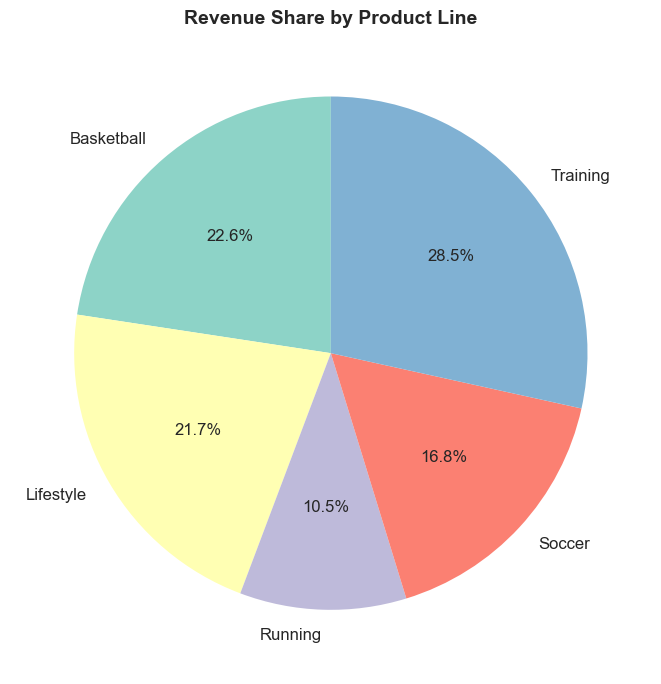

In [20]:
rev_by_pl = df_clean.groupby('Product_Line')['Revenue'].sum()

plt.figure(figsize=(7,7))
plt.pie(
    rev_by_pl,
    labels=rev_by_pl.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set3')
)
plt.title('Revenue Share by Product Line', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### The pie chart illustrates the percentage of total revenue contributed by each product line. A few lines, such as Training , occupy the largest slices, confirming their dominant role in overall sales. Smaller slices indicate niche product lines that may need targeted strategies or could represent future growth areas.


---

### 12. Count plot of orders by Region and Sales Channel

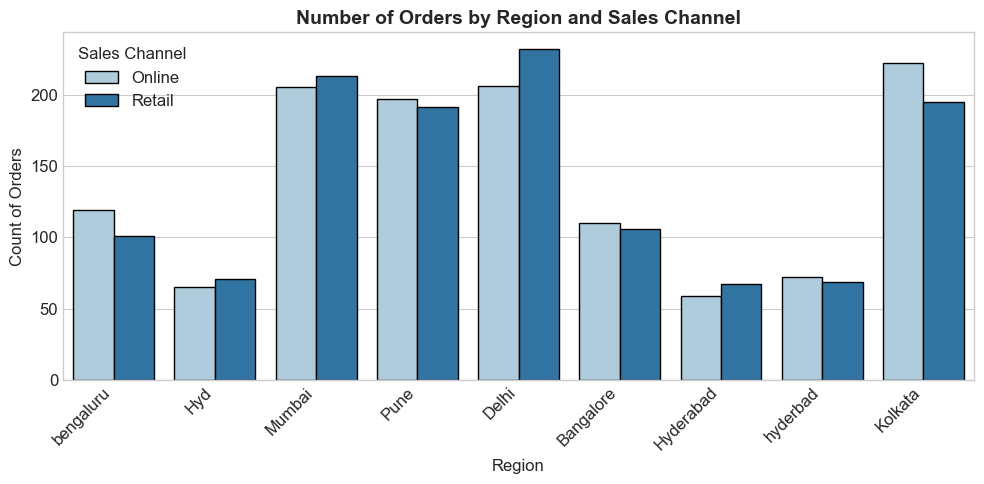

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_clean,
    x='Region',
    hue='Sales_Channel',
    palette='Paired',
    edgecolor='black'
)
plt.xticks(rotation=45, ha='right')
plt.title('Number of Orders by Region and Sales Channel', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Count of Orders', fontsize=12)
plt.legend(title='Sales Channel')
plt.tight_layout()
plt.show()


#### This count plot shows how many orders each region generates, split by Online and Retail channels. Some regions rely heavily on a single channel, while others have a more balanced mix. These patterns help Nike decide where to expand online presence, open or close physical stores, and design region‑specific channel strategies.


---

### 13.  Pairplot for numeric variables

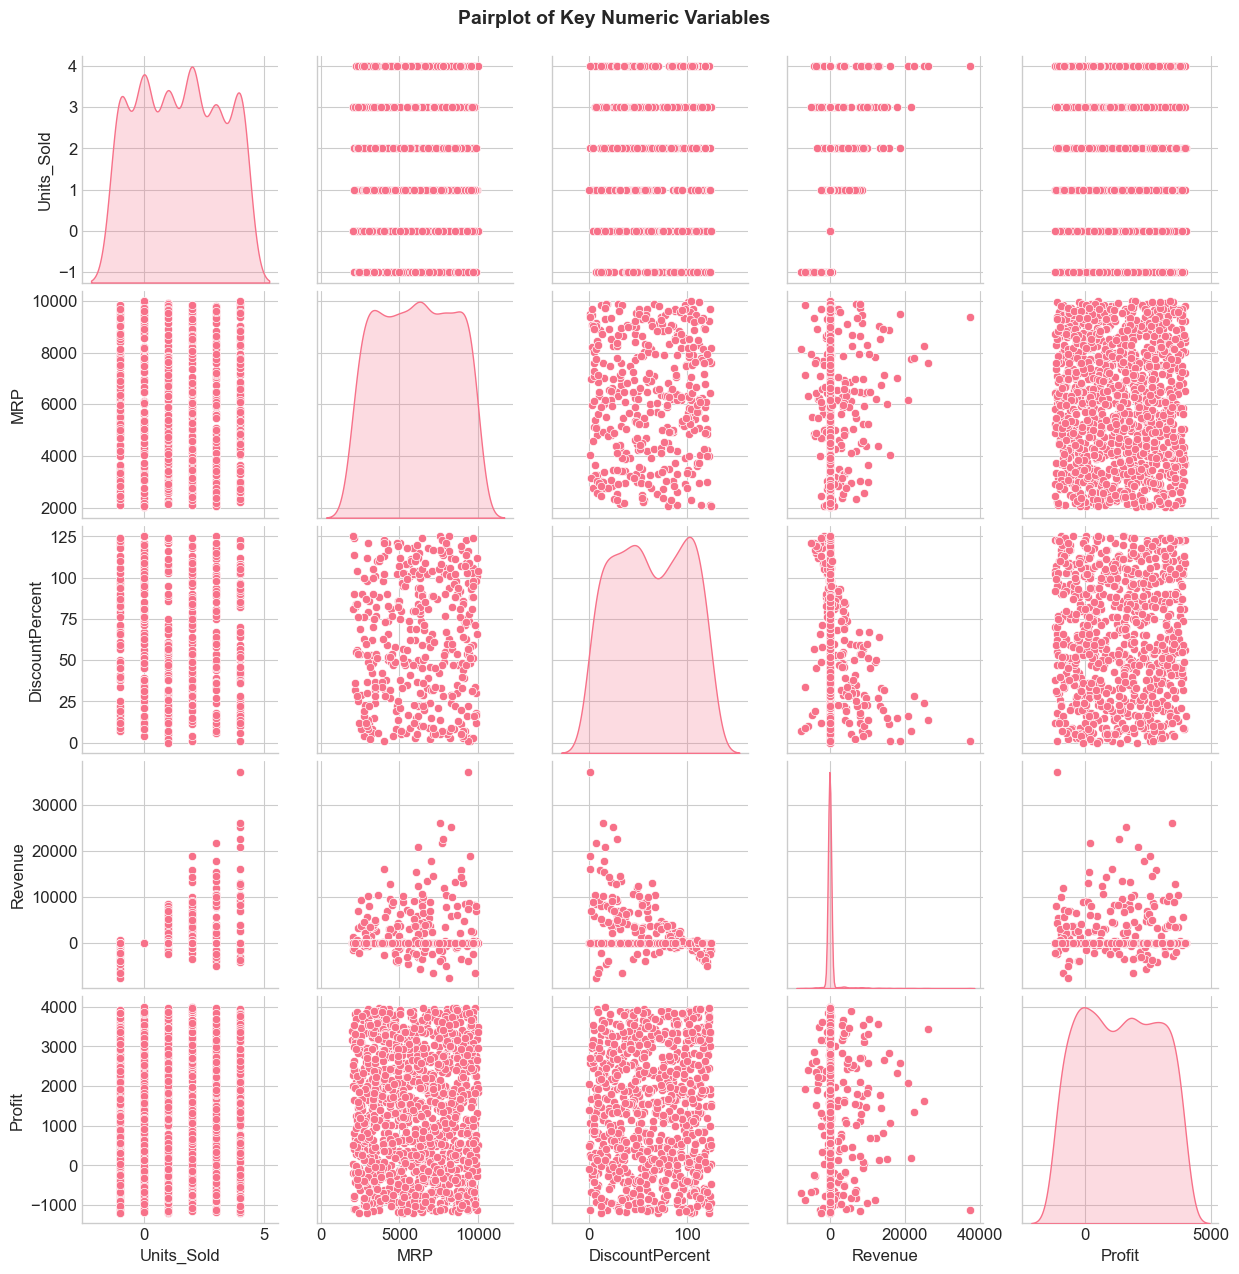

In [14]:
num_cols_small = ['Units_Sold', 'MRP', 'DiscountPercent', 'Revenue', 'Profit']
sns.pairplot(df_clean[num_cols_small], diag_kind='kde', palette='husl')
plt.suptitle('Pairplot of Key Numeric Variables', y=1.02, fontsize=14, fontweight='bold')
plt.show()


#### The pairplot provides a visual overview of the relationships between major numeric variables such as Units_Sold, MRP, DiscountPercent, Revenue, and Profit. Diagonal plots show the distribution of each variable, while off‑diagonal scatter plots reveal trends or clusters. This high‑level view supports and confirms more detailed findings from individual charts.


---

## 3.5 Key Findings from Nike Sales Analysis

### 📊 Product Line Performance Varies Dramatically

- **Training and Lifestyle** products generate the highest revenue
- **Running products** show strong online preference (low retail sales)
- **Basketball products** maintain balanced channel distribution
- Strategic focus should prioritize high-performing categories while optimizing underperforming lines

**Actionable Insight:** Allocate marketing budgets proportionally to revenue-generating product lines. Training and Lifestyle deserve increased investment.

---

### 🛒 Sales Channel Strategy Needs Product-Specific Approach

- **Online channel** dominates for Training, Lifestyle, and Running products
- **Retail channel** shows competitive performance for Basketball and select categories
- Channel preference varies significantly by product type

**Actionable Insight:** Avoid one-size-fits-all channel strategies. Invest in digital marketing for Training/Running; maintain strong retail presence for Basketball.

---

### 💰 Discounts Significantly Erode Profitability

- **Negative correlation** between DiscountPercent and Profit observed
- Higher discount rates consistently associated with lower profit margins
- Aggressive discounting may drive volume but damages bottom line

**Actionable Insight:** Implement controlled discounting strategies. Focus on value messaging over price cuts to maintain healthy margins.

---

### 🌍 Regional Performance Shows Geographic Opportunities

- Certain regions generate disproportionately higher revenue
- Regional preferences exist for specific product lines
- Geographic patterns suggest untapped market potential

**Actionable Insight:** Expand presence in high-performing regions. Tailor product mix and marketing to regional preferences for maximum impact.

---

### 📈 Revenue and Profit Don't Always Align

- High-revenue product lines may not be the most profitable
- Profit margins vary significantly across categories
- **Correlation analysis reveals** Revenue-Profit relationship is strong but not perfect

**Actionable Insight:** Track both revenue and profit metrics. Optimize product mix for profitability, not just sales volume.

---

### 🔗 Visualization Uncovers Hidden Patterns

- Correlation heatmap alone would miss critical business insights
- Channel preferences by product line only visible through grouped visualizations
- Multi-dimensional analysis reveals opportunities invisible in simple statistics

**Actionable Insight:** Organizations that rely solely on summary statistics and correlation matrices will miss strategic opportunities. Visualization is essential for actionable insights.


In [25]:
# Quick summary statistics

print(f"Total transactions: {len(df_clean):,}")

# Skip date range for now if it causes issues
print(f"Number of regions: {df_clean['Region'].nunique()}")
print(f"Number of product lines: {df_clean['Product_Line'].nunique()}")

# Top product line
top_product = df_clean.groupby('Product_Line')['Revenue'].sum().idxmax()
top_product_pct = (df_clean.groupby('Product_Line')['Revenue'].sum().max() / df_clean['Revenue'].sum() * 100).round(1)
print(f"\nTop product line: {top_product} ({top_product_pct}%)")

# Online percentage
online_pct = (df_clean[df_clean['Sales_Channel']=='Online']['Revenue'].sum() / df_clean['Revenue'].sum() * 100).round(1)
print(f"Online channel: {online_pct}%")

# Top region
top_region = df_clean.groupby('Region')['Revenue'].sum().idxmax()
print(f"Top revenue region: {top_region}")

# Highest margin region
region_stats = df_clean.groupby('Region').agg({'Profit': 'sum', 'Revenue': 'sum'})
region_stats['Margin'] = (region_stats['Profit'] / region_stats['Revenue'] * 100).round(1)
highest_margin_region = region_stats['Margin'].idxmax()
highest_margin_value = region_stats['Margin'].max()
print(f"Highest margin region: {highest_margin_region} ({highest_margin_value}%)")

# Top 3 regions
top_3_regions = df_clean.groupby('Region')['Revenue'].sum().nlargest(3)
top_3_pct = (top_3_regions.sum() / df_clean['Revenue'].sum() * 100).round(1)
print(f"\nTop 3 regions account for: {top_3_pct}% of revenue")


Total transactions: 2,500
Number of regions: 9
Number of product lines: 5

Top product line: Training (28.5%)
Online channel: 55.0%
Top revenue region: Kolkata
Highest margin region: Hyd (28053.6%)

Top 3 regions account for: 53.3% of revenue


---